## Pandas practice 2
범위 : transformation, groupby , visualization_timeseries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

orders = pd.DataFrame({
    '주문일자': ['2026-01-03', '2026-01-05', '2026-01-05', '2026-01-08', '2026-01-10',
             '2026-02-02', '2026-02-10', '2026-02-18', '2026-03-03', '2026-03-11'],
    '고객명': ['김철수', '이영희', '박민수', '최지영', '정다은', '홍길동', '강민호', '오세훈', '장미라', '서지수'],
    '지역': ['서울', '부산', '서울', '대전', '부산', '서울', '서울', '부산', '대전', '서울'],
    '카테고리': ['전자', '식품', '전자', '패션', '식품', '전자', '패션', '식품', '전자', '패션'],
    '상품명': ['노트북', '사과', '마우스', '자켓', '우유', '키보드', '운동화', '라면', '모니터', '가방'],
    '수량': [1, 10, 2, 1, 3, 1, 2, 5, 1, 1],
    '단가': [1500000, 3000, 25000, 120000, 2500, 50000, 90000, 4000, 350000, 70000]
})

orders['주문일자'] = pd.to_datetime(orders['주문일자'])
orders['총액'] = orders['수량'] * orders['단가']
orders
     

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000
1,2026-01-05,이영희,부산,식품,사과,10,3000,30000
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000
4,2026-01-10,정다은,부산,식품,우유,3,2500,7500
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000
7,2026-02-18,오세훈,부산,식품,라면,5,4000,20000
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000


# apply / map
1. 총액이 100000 이상이면 '고가', 아니면 '일반'을 반환하는 가격등급 열을 apply로 만드시오.
2. 지역 코드 맵을 사용해 지역코드 열을 map으로 만드시오. (서울:S, 부산:B, 대전:D)

In [ ]:
def grade(x):                         
    if x >= 100000:
        return '고가'
    else:
        return '일반'
orders['가격등급'] = orders['총액'].apply(grade)

region_map = {'서울':'S', '부산':'B', '대전':'D'}
orders['지역코드'] = orders['지역'].map(region_map)
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,가격등급,지역코드
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S
1,2026-01-05,이영희,부산,식품,사과,10,3000,30000,일반,B
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D
4,2026-01-10,정다은,부산,식품,우유,3,2500,7500,일반,B
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S
7,2026-02-18,오세훈,부산,식품,라면,5,4000,20000,일반,B
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,고가,D
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,일반,S


# 2. replace / np.where
1. 카테고리의 '식품'을 '식음료'로 바꾸시오.
2. 총액이 100000 이상이면 VIP, 아니면 NORMAL인 고객등급 열을 np.where로 만드시오.
- 주의: 이후 집계 결과에는 변경된 카테고리명(식음료)이 반영된다.

In [4]:
orders['카테고리'] = orders['카테고리'].replace({'식품':'식음료'})
orders['고객등급'] = np.where(orders['총액'] >= 100000, 'VIP', 'NORMAL')
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,가격등급,지역코드,고객등급
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,고가,S,VIP
1,2026-01-05,이영희,부산,식음료,사과,10,3000,30000,일반,B,NORMAL
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,일반,S,NORMAL
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,고가,D,VIP
4,2026-01-10,정다은,부산,식음료,우유,3,2500,7500,일반,B,NORMAL
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,일반,S,NORMAL
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,고가,S,VIP
7,2026-02-18,오세훈,부산,식음료,라면,5,4000,20000,일반,B,NORMAL
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,고가,D,VIP
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,일반,S,NORMAL


# 3. np.select
- 총액 기준으로 주문등급 열을 만드시오.
  - 500000 이상: A
  - 100000 이상 500000 미만: B
  - 그 외: C

In [ ]:
cond = [
    orders['총액'] >= 500000,
    (orders['총액'] >= 100000) & (orders['총액'] < 500000)  # 정답: (orders['총액'] >= 100000
]
choice = ['A', 'B']
orders['주문등급'] = np.select(cond, choice, default='C')

# 4. concat
- 신규 주문 2건이 아래와 같이 들어왔다. new_orders를 orders와 세로로 연결한 result_concat을 만드시오.

- 주의:
  - 새 주문 데이터에는 아직 일부 파생 컬럼이 없을 수 있다.
  - 필요하면 orders의 컬럼 구조에 맞춰 정리한 뒤 연결해도 된다.

In [ ]:
new_orders = pd.DataFrame({
    '주문일자': pd.to_datetime(['2026-03-20', '2026-03-25']),
    '고객명': ['한지민', '이도윤'],
    '지역': ['부산', '서울'],
    '카테고리': ['전자', '식음료'],
    '상품명': ['이어폰', '커피'],
    '수량': [2, 4],
    '단가': [80000, 5000],
    '총액': [160000, 20000]
})
# 정답 : orders에 있는 파생 컬럼 구조에 맞춰 새 주문 데이터도 정리
new_orders['가격등급'] = new_orders['총액'].apply(lambda x: '고가' if x >= 100000 else '일반')
new_orders['지역코드'] = new_orders['지역'].map(region_map)
new_orders['고객등급'] = np.where(new_orders['총액'] >= 100000, 'VIP', 'NORMAL')
new_orders['주문등급'] = np.select(
    [new_orders['총액'] >= 500000, new_orders['총액'] >= 100000],
    ['A', 'B'],
    default='C'
)

result_concat= pd.concat([orders, new_orders])


# 5. merge
- 고객 등급표를 결합하시오. 고객명 기준으로 left join 하여 orders_grade를 만드시오.

- 확인 포인트:
  - 등급표에 없는 고객은 회원등급이 NaN으로 남는다.
  - left join이므로 orders의 행 수는 유지된다.

In [ ]:
# 정답 :
grade_df = pd.DataFrame({
    '고객명': ['김철수', '이영희', '홍길동', '강민호'],
    '회원등급': ['Gold', 'Silver', 'Gold', 'Bronze']
})

# 등급표에 없는 고객은 회원등급이 NaN으로 남고,
# left join이므로 orders의 행 수는 유지된다.


orders_grade= pd.merge(orders, new_orders, on='고객명', how='left')

# 6. pivot_table
- 지역별, 카테고리별 총액 합계를 피벗 테이블로 만드시오.
- 참고:
  - 집계 결과에 따라 값이 없는 조합은 NaN으로 보일 수 있다.

In [ ]:
orders.pivot_table(index='지역', columns='카테고리', values='총액', aggfunc='sum')
# 정답 : orders.pivot_table(
#          index='지역', columns='카테고리', values='총액', aggfunc='sum', fill_value =0 )

카테고리,식품,전자,패션
지역,,,
대전,NaN,350000.0,120000.0
부산,57500.0,NaN,NaN
서울,NaN,1600000.0,250000.0


# 7. melt
- 아래 wide_df를 long 형태로 바꾸시오. 열 이름은 월, 매출을 사용하시오.

In [ ]:
wide_df = pd.DataFrame({
    '상품명': ['노트북', '마우스'],
    '1월': [100, 50],
    '2월': [120, 60],
    '3월': [110, 70]
})

pd.melt(
    wide_df,
    id_vars='상품명',                   
    value_vars=['1월','2월','3월'], # 정답 : 이거빼도 되는듯
    var_name='월',                  
    value_name='매출'                
)

,상품명,월,매출
0,노트북,1월,100
1,마우스,1월,50
2,노트북,2월,120
3,마우스,2월,60
4,노트북,3월,110
5,마우스,3월,70


# 8. groupby 기본
1. 카테고리별 총액 합계를 구하시오.
2. 지역별 평균 총액을 구하시오.
- 가능하면 결과를 각각 다른 변수에 저장해보시오.

In [15]:
cat_s= orders.groupby('카테고리')['총액'].sum()
reg_s= orders.groupby('지역')['총액'].mean()
print(cat_s)
print(reg_s)

카테고리
식품      57500
전자    1950000
패션     370000
Name: 총액, dtype: int64
지역
대전    235000.000000
부산     19166.666667
서울    370000.000000
Name: 총액, dtype: float64


# 9. agg / named aggregation
- 카테고리별로 아래 값을 한 번에 구하시오.
  - 주문수
  - 평균총액
  - 최고총액

In [17]:
orders.groupby('카테고리').agg(
    주문수 = ('수량','count'),
    평균총액 = ('총액','mean'),
    최고총액 = ('총액','max')
)

,주문수,평균총액,최고총액
카테고리,,,
식품,3,19166.666667,30000
전자,4,487500.000000,1500000
패션,3,123333.333333,180000


# 10. transform
- 카테고리 평균 총액을 각 행에 붙이고, 평균대비차이 열을 만드시오.

In [ ]:
orders['평균총액'] = orders.groupby('카테고리')['총액'].transform('mean')

orders['평균대비'] = orders['총액'] - orders['평균총액']
# 정답(추가) : pd.options.display.float_format = '{:,.0f}'.format
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,평균총액,평균대비
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,487500.000000,1.012500e+06
1,2026-01-05,이영희,부산,식품,사과,10,3000,30000,19166.666667,1.083333e+04
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,487500.000000,-4.375000e+05
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,123333.333333,-3.333333e+03
4,2026-01-10,정다은,부산,식품,우유,3,2500,7500,19166.666667,-1.166667e+04
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,487500.000000,-4.375000e+05
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,123333.333333,5.666667e+04
7,2026-02-18,오세훈,부산,식품,라면,5,4000,20000,19166.666667,8.333333e+02
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,487500.000000,-1.375000e+05
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,123333.333333,-5.333333e+04


# 11. 날짜 처리
1. 주문월 열을 만드시오.
2. 주문요일명 열을 만드시오.
- 참고:
 - day_name()은 기본적으로 영어 요일명을 반환한다.

In [21]:
orders['월'] = orders['주문일자'].dt.month
orders['요일명'] = orders['주문일자'].dt.day_name()
orders

,주문일자,고객명,지역,카테고리,상품명,수량,단가,총액,평균총액,평균대비,월,요일명
0,2026-01-03,김철수,서울,전자,노트북,1,1500000,1500000,487500.000000,1.012500e+06,1,Saturday
1,2026-01-05,이영희,부산,식품,사과,10,3000,30000,19166.666667,1.083333e+04,1,Monday
2,2026-01-05,박민수,서울,전자,마우스,2,25000,50000,487500.000000,-4.375000e+05,1,Monday
3,2026-01-08,최지영,대전,패션,자켓,1,120000,120000,123333.333333,-3.333333e+03,1,Thursday
4,2026-01-10,정다은,부산,식품,우유,3,2500,7500,19166.666667,-1.166667e+04,1,Saturday
5,2026-02-02,홍길동,서울,전자,키보드,1,50000,50000,487500.000000,-4.375000e+05,2,Monday
6,2026-02-10,강민호,서울,패션,운동화,2,90000,180000,123333.333333,5.666667e+04,2,Tuesday
7,2026-02-18,오세훈,부산,식품,라면,5,4000,20000,19166.666667,8.333333e+02,2,Wednesday
8,2026-03-03,장미라,대전,전자,모니터,1,350000,350000,487500.000000,-1.375000e+05,3,Tuesday
9,2026-03-11,서지수,서울,패션,가방,1,70000,70000,123333.333333,-5.333333e+04,3,Wednesday


# 12. 시계열 인덱스와 리샘플링
1. 주문일자를 인덱스로 설정한 ts_orders를 만드시오.
2. 월말 기준 월별 총액 합계를 구하시오.

In [27]:
ts_orders = orders.set_index('주문일자')
mon_s=ts_orders['총액'].resample('ME').sum()

# 13. rolling
- 일자별 총액 합계를 구한 뒤 3일 이동평균을 계산하시오.

- 참고:
  - 일 단위로 리샘플링하면 주문이 없는 날짜도 포함될 수 있다.

In [30]:
daily_s = ts_orders['총액'].resample('D').sum()

# 정답(추가) : rolling_mean = daily_s.to_frame(name='총액')
rolling_mean = daily_s.rolling(3).mean()
rolling_mean

주문일자
2026-01-03              NaN
2026-01-04              NaN
2026-01-05    526666.666667
2026-01-06     26666.666667
2026-01-07     26666.666667
                  ...      
2026-03-07         0.000000
2026-03-08         0.000000
2026-03-09         0.000000
2026-03-10         0.000000
2026-03-11     23333.333333
Freq: D, Name: 총액, Length: 68, dtype: float64

# 14. shift / diff / pct_change
- 일자별 총액 합계를 기준으로
  - 전일총액
  - 전일대비
  - 변화율 열을 만드시오.
- 참고:
 - 전일 값이 0인 경우 변화율 해석에 주의한다.

In [ ]:

change_df = daily_s.to_frame(name='총액')
change_df['전일총액'] = change_df['총액'].shift(1)
change_df['전일대비'] = change_df['총액'].diff()

# 전일 값이 0인 경우 변화율 해석에 주의한다.
# 전일 값이 0인 경우 나눗셈에서 0으로 나누기 발생 → inf
# 전일과 오늘 모두 0인 경우 0 / 0 → 정의 불가 → NaN
# 변화율은 전일 값이 0이 아닌 경우에만 의미가 있다.
# 전일 값이 0이면 비율이 아니라 절대 변화량(diff)로 해석해야 한다.
change_df['변화율'] = change_df['총액'].pct_change() * 100
change_df.head(10)

# 15. 시각화
1. 월별 총액 합계를 막대 그래프로 그리시오.
2. 일자별 총액과 3일 이동평균을 선 그래프로 그리시오.

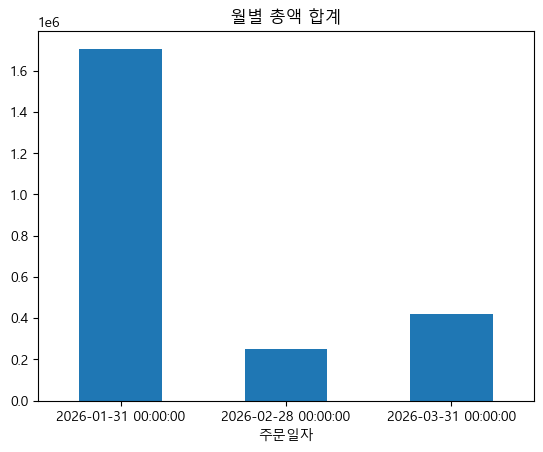

KeyError: "None of [Index(['총액', '이동평균_3일'], dtype='str', name='주문일자')] are in the [index]"

In [31]:
mon_s.plot(kind='bar', title='월별 총액 합계')
plt.xticks(rotation=0)
plt.show()

rolling_mean[['총액', '이동평균_3일']].plot(title='일자별 총액과 3일 이동평균')
plt.show()